In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/churn-modellingcsv/Churn_Modelling.csv


In [25]:
df = pd.read_csv('/kaggle/input/churn-modellingcsv/Churn_Modelling.csv')

In [26]:
df.shape

(10000, 14)

In [27]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [28]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [29]:
df.groupby('Geography')['Exited']

<Axes: ylabel='count'>

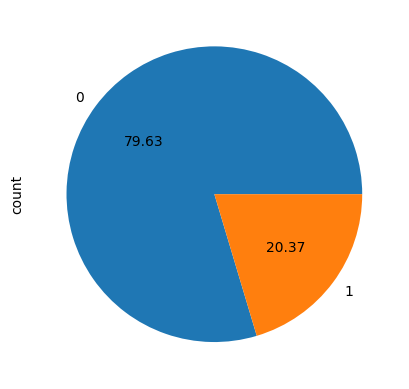

In [30]:
df['Exited'].value_counts().plot(kind='pie',autopct='%0.2f')

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [34]:
df.duplicated().sum()

0

In [35]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [36]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [37]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [38]:
df = pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)

In [39]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [42]:
X = df.drop(columns=['Exited'])
y = df['Exited']

In [43]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [44]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [45]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [47]:
X_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]])

In [50]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [70]:
model = Sequential()
model.add(Dense(11,activation='relu',input_dim=11)) 
model.add(Dense(11,activation='relu',))
model.add(Dense(1,activation='sigmoid'))

In [71]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [76]:
# model.compile(loss='binary_crossentropy',optimizer='Adam')
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [92]:
# model.fit(X_train_scaled,y_train,epochs=10)
history = model.fit(X_train_scaled,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8651 - loss: 0.3326 - val_accuracy: 0.8531 - val_loss: 0.3457
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8629 - loss: 0.3384 - val_accuracy: 0.8562 - val_loss: 0.3442
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8584 - loss: 0.3374 - val_accuracy: 0.8544 - val_loss: 0.3449
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8599 - loss: 0.3377 - val_accuracy: 0.8562 - val_loss: 0.3448
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8575 - loss: 0.3372 - val_accuracy: 0.8494 - val_loss: 0.3476
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8565 - loss: 0.3433 - val_accuracy: 0.8550 - val_loss: 0.3463
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8635 - loss: 0.3342 - val_accuracy: 0.8537 - val_loss: 0.3471
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8659 - loss: 0.3297 - val_accu

In [95]:
model.layers[0].get_weights()

[array([[ 2.70040005e-01,  2.82948036e-02, -7.47529343e-02,
          9.14688862e-04,  1.82944506e-01, -1.04904808e-01,
         -2.66811877e-01, -6.94084316e-02, -1.56253204e-02,
         -8.10831860e-02, -4.80097681e-01],
        [ 6.30314410e-01, -6.94242120e-01, -9.14973393e-02,
         -3.10024470e-01, -3.02162349e-01, -8.62246394e-01,
          4.31441963e-02,  5.21517277e-01, -8.80495310e-01,
          7.04296291e-01,  1.14274034e-02],
        [-3.36281598e-01,  3.39750648e-02, -1.13239549e-01,
          5.66170365e-02,  4.13094491e-01, -1.34473056e-01,
          8.29573870e-02,  1.35605801e-02, -5.51767945e-02,
          2.94255354e-02, -1.05552113e+00],
        [-9.44097191e-02, -4.34761763e-01,  2.88846582e-01,
         -9.07924592e-01, -7.81565905e-01, -4.24266547e-01,
         -4.88335967e-01,  2.32297912e-01, -3.47226970e-02,
          1.66611046e-01,  2.16695741e-01],
        [ 3.41418266e-01, -7.25672394e-03,  1.19281363e+00,
         -1.22493744e+00, -3.02807003e-01, -

In [96]:
model.layers[1].get_weights()

[array([[ 4.72515941e-01, -1.60764735e-02, -1.88639641e-01,
         -1.27214539e+00, -3.55408117e-02,  4.43460256e-01,
         -6.38187379e-02,  1.05874486e-01, -1.23809147e+00,
          5.07610142e-01, -2.77878903e-02],
        [-5.92507303e-01,  3.08914427e-02,  7.82004297e-01,
         -1.83547765e-01, -6.89974502e-02, -1.57187656e-01,
          1.83326036e-01,  2.70032555e-01,  1.45257473e-01,
          3.16045493e-01,  5.07063009e-02],
        [ 8.67477536e-01,  2.01368272e-01, -8.42491223e-04,
         -7.93101728e-01,  1.19324946e+00, -3.32728982e-01,
         -1.42699635e+00, -2.68258065e-01, -8.16746414e-01,
          5.62508345e-01, -6.46782294e-02],
        [ 4.02463287e-01,  4.86348569e-01, -1.71005145e-01,
          6.38591945e-01,  4.01924908e-01, -9.46600080e-01,
          9.55729708e-02, -1.15701653e-01, -6.87679574e-02,
         -5.79700768e-01,  6.16765693e-02],
        [-1.66002393e-01,  1.32799596e-01,  3.11553013e-02,
         -6.14783645e-01,  1.33590609e-01,  

In [97]:
y_log = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [102]:
y_pred = np.where(y_log>0.5,1,0)

In [103]:
from sklearn.metrics  import accuracy_score

In [104]:
accuracy_score(y_test,y_pred)

0.8565

In [105]:
import matplotlib.pyplot as plt

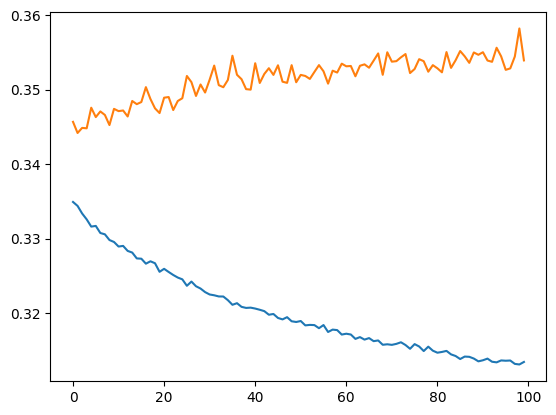

In [106]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

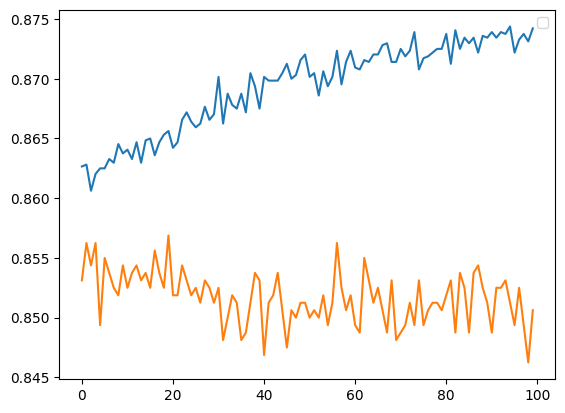

In [111]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend()

In [110]:
history.history

{'accuracy': [0.8626562356948853,
  0.8628125190734863,
  0.8606250286102295,
  0.8620312213897705,
  0.862500011920929,
  0.862500011920929,
  0.86328125,
  0.8629687428474426,
  0.8645312786102295,
  0.8637499809265137,
  0.864062488079071,
  0.86328125,
  0.8646875023841858,
  0.8629687428474426,
  0.8648437261581421,
  0.8650000095367432,
  0.8635937571525574,
  0.8646875023841858,
  0.8653125166893005,
  0.8656250238418579,
  0.8642187714576721,
  0.8646875023841858,
  0.8665624856948853,
  0.8671875,
  0.866406261920929,
  0.8659374713897705,
  0.8662499785423279,
  0.8676562309265137,
  0.8665624856948853,
  0.8670312762260437,
  0.8701562285423279,
  0.8662499785423279,
  0.8687499761581421,
  0.8678125143051147,
  0.8675000071525574,
  0.8687499761581421,
  0.8671875,
  0.8704687356948853,
  0.8693749904632568,
  0.8675000071525574,
  0.8701562285423279,
  0.8698437213897705,
  0.8698437213897705,
  0.8698437213897705,
  0.8704687356948853,
  0.8712499737739563,
  0.8700000047